In [1]:
import os
os.chdir('/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/src')

In [2]:
from operator import itemgetter
from tqdm import tqdm
import time
from datetime import datetime
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import importlib

import seaborn as sns

In [3]:
from dataloaders import dataset_ST_MultiPoint
# from dataloaders import load_dataset
# from loss import losses_SparseData
# from models import models_SparseData
# from optimizer import load_optimizer

from subprocess import Popen

In [4]:
inference_run_path = '/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/results/test_predictions/STAINet_PSTAINet-IB_PSTAINet-ILB_PSTAINet-ILRB_20251209_100741/predictions'
model_list = ["STAINet","PSTAINet-IB","PSTAINet-ILB","PSTAINet-ILRB"]

# Data

In [6]:
json_file = "/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/config/ST_MultiPoint_STDisNet_SAGW_PI_ERA5.json" #config_files_1d/lstm_att_1.json
dict_files = {}
with open(json_file) as f:
    dict_files = json.load(f)
    print(f"Read data.json: {dict_files}")

Read data.json: {'cuda_device': 'cuda:0', 'seed': 42, 'entity': 'gsartor-unito', 'experiment_name': 'ST_MultiPoint', 'run_name': 'PI_S_ref', 'comments': None, 'wandb_mode': 'offline', 'wandb_dir': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/results/results_ST_MultiPoint/logs', 'save_model_dir': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/results/results_ST_MultiPoint/runs', 'dtm_nc': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/dtm_ROI.nc', 'weather_nc_path': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/era5land_2000_2024_weekly.nc', 'weather_dtm': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/era5land_dtm.nc', 'wtd_csv_path': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/dataset_wtd_roi.csv', 'wtd_shp': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/shapefile/underground_wtd_sensor_roi.shp', 'piedmont_shp': '/leonardo_scratch/fast/IscrC_DL4STP/water-pinns/data/shapefile/piemonte_admin_boundaries.shp', 'recharge_areas_shp': '/leonardo_

In [7]:
ds = dataset_ST_MultiPoint.Dataset_ST_MultiPoint(dict_files)

    Loading weather data... 

/leonardo_scratch/fast/IscrC_DL4STP/.venv/lib64/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gmt' loading failed:
Error loading GMT shared library at 'libgmt.so'.
libgmt.so: cannot open shared object file: No such file or directory
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


Done!
    Loading dtm... Done!
    Loading Piedmont Shapefiles... 

/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/src/dataloaders/dataset_ST_MultiPoint.py:101: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  clipped_buffer = clipped.buffer(buffer_recharge)


Done!
    Loading underground water data... Done!
    Norm factors:
{'target_means': np.float64(297.1249160768408), 'target_stds': np.float64(73.38987997145817), 'dtm_mean': <xarray.DataArray '__xarray_dataarray_variable__' ()> Size: 4B
array(1139.4907, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0, 'dtm_std': <xarray.DataArray '__xarray_dataarray_variable__' ()> Size: 4B
array(884.7991, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0, 'lat_mean': np.float64(44.800499999999964), 'lat_std': np.float64(0.3169655454549103), 'lon_mean': np.float64(7.375499999999998), 'lon_std': np.float64(0.4326943495034695), 'weather_mean': <xarray.Dataset> Size: 24B
Dimensions:      ()
Coordinates:
    spatial_ref  int64 8B 0
Data variables:
    tp           float32 4B 0.001774
    t2m          float32 4B 280.5
    pev          float32 4B -0.001865
    smlt         float32 4B 0.000512, 'weather_std': <xarray.Dataset> Size: 24B
Dimensions:      ()
Coordinates:
    spatial_ref  int64 8B 0

In [27]:
ds_truth = pd.read_csv(f"{inference_run_path}/{model_list[0]}_TS_true.csv", index_col=0, parse_dates=True, dtype=np.float32)
ds_truth = ds_truth.loc[ds_truth.index >= np.datetime64("2022-01-01")]

In [20]:
def load_pred_ts(path, model_list, prediction_object_name,
                 from_date = None):
    data_dict = {}
    # load models
    
    for i in range(len(model_list)):
        ds = pd.read_csv(f"{path}/{model_list[i]}_TS_{prediction_object_name}.csv",
                        index_col=0,
                        parse_dates=True,
                        dtype=np.float32)
        if from_date:
            ds = ds.loc[ds.index >= np.datetime64(from_date)]
        data_dict[model_list[i]] = ds
        
    return data_dict
    # true data

In [31]:
model_list = ["STAINet","PSTAINet-IB","PSTAINet-ILB","PSTAINet-ILRB"]

In [32]:
dict_pred_gwl = load_pred_ts(inference_run_path,
                        model_list,
                        prediction_object_name = "pred",
                        from_date = "2022-01-01")

In [33]:
dict_pred_d = load_pred_ts(inference_run_path,
                        model_list[1:],
                        prediction_object_name = "D")

dict_pred_deltagw = load_pred_ts(inference_run_path,
                        model_list[1:],
                        prediction_object_name = "DeltaGW")

dict_pred_laggwl = load_pred_ts(inference_run_path,
                        model_list[1:],
                        prediction_object_name = "lagGWL")

dict_pred_r = load_pred_ts(inference_run_path,
                        model_list[1:],
                        prediction_object_name = "R")

In [23]:
def ts_plot_components(sensor_id,
                       ds_truth,
                       dict_pred_gwl,
                       dict_pred_d,
                       dict_pred_deltagw,
                       dict_pred_laggwl,
                       dict_pred_r,
                       color_dict, 
                       physics_model_list,
                       figsize = (10,10)
                       ):
    
    
    fig, ax = plt.subplots(5,1,figsize = figsize)
    
    # GWL true vs pred
    
    ds_truth[sensor_id].plot(label = "Truth", ax = ax[0],
                             marker = "o", lw = 3,
                             markersize = 2)
    
    gwl_model_list = list(dict_pred_gwl.keys())
    #physics_model_list = list(dict_pred_deltagw.keys())
    
    for model in gwl_model_list:
        dict_pred_gwl[model][sensor_id].plot(label = model, ax = ax[0],
                                      marker = "o", lw = 1,
                                      markersize = 2,
                                      color = color_dict[model])
    
    for model in physics_model_list:
        dict_pred_laggwl[model][sensor_id].plot(label = model, ax = ax[1],
                                      marker = "o", lw = 1,
                                      markersize = 2,
                                      color = color_dict[model])
    
        dict_pred_deltagw[model][sensor_id].plot(label = model, ax = ax[2],
                                      marker = "o", lw = 1,
                                      markersize = 2,
                                      color = color_dict[model])

        dict_pred_d[model][sensor_id].plot(label = model, ax = ax[3],
                                      marker = "o", lw = 1,
                                      markersize = 2,
                                      color = color_dict[model])
    
        dict_pred_r[model][sensor_id].plot(label = model, ax = ax[4],
                                      marker = "o", lw = 1,
                                      markersize = 2,
                                      color = color_dict[model])

    ax[0].set_title("GWL True vs Predictions")
    ax[1].set_title("Predicted GWL lag")
    ax[2].set_title(r"Predicted $\hat{\Delta_{GW}}$")
    ax[3].set_title(r"Predicted $\hat{\mathcal{D}}$")
    ax[4].set_title(r"Predicted $\hat{\mathcal{R}}$")
    
    ax[0].legend()
    ax[1].legend()
    ax[2].legend()
    ax[3].legend()
    ax[4].legend()
    
    plt.tight_layout() 

In [24]:
color_dict = {"STAINet":"tab:brown",
              "PSTAINet-IB":"tab:orange",
              "PSTAINet-ILB":"darkgreen",
              "PSTAINet-ILRB":"darkmagenta"}

# Plot

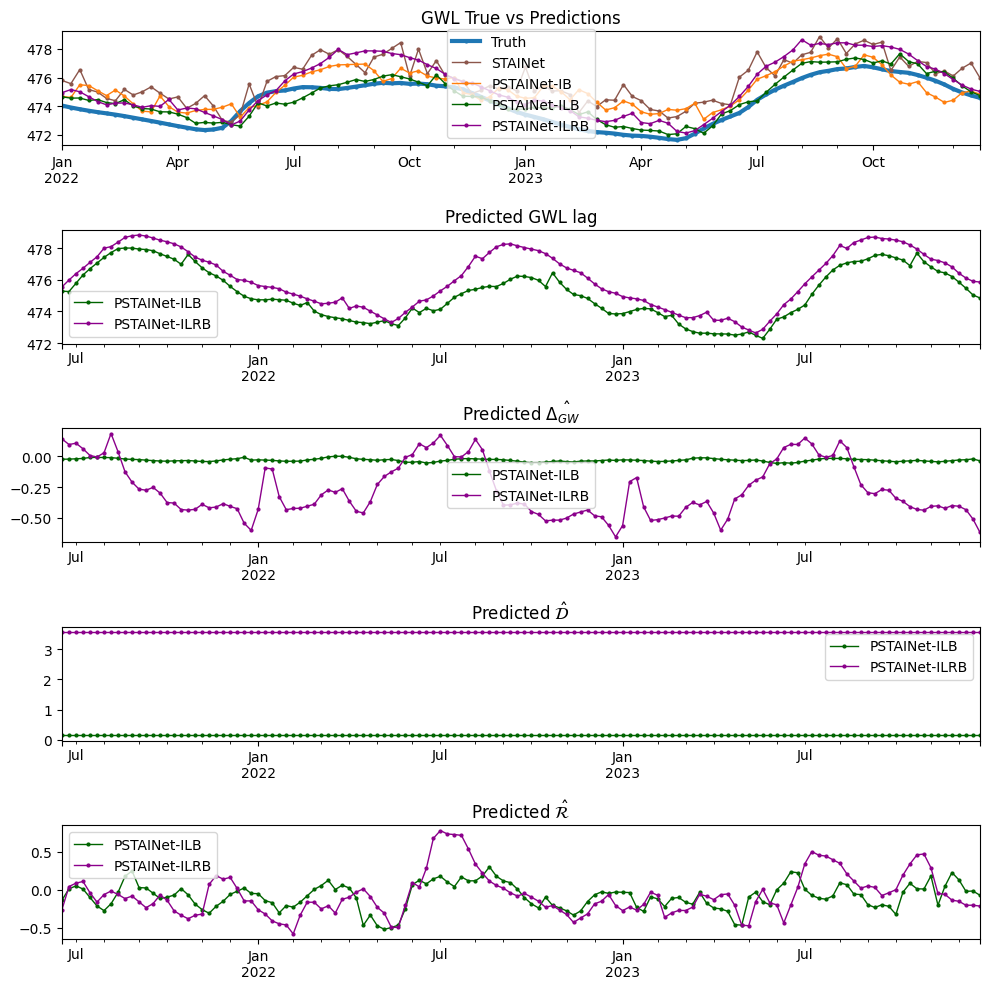

In [34]:
ts_plot_components("00407810001",
                       ds_truth,
                       dict_pred_gwl,
                       dict_pred_d,
                       dict_pred_deltagw,
                       dict_pred_laggwl,
                       dict_pred_r,
                       color_dict,
                       physics_model_list = ["PSTAINet-ILB","PSTAINet-ILRB"])

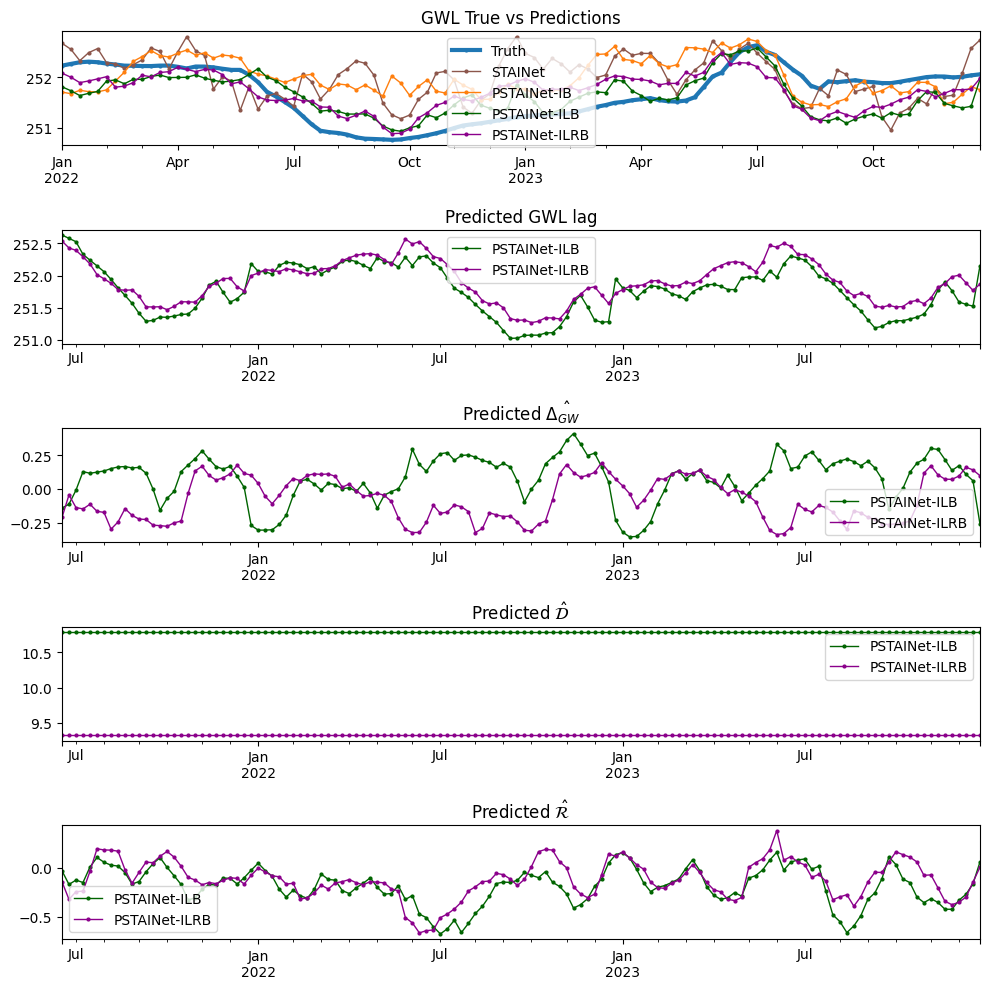

In [35]:
ts_plot_components("00417910001",
                       ds_truth,
                       dict_pred_gwl,
                       dict_pred_d,
                       dict_pred_deltagw,
                       dict_pred_laggwl,
                       dict_pred_r,
                       color_dict,
                       physics_model_list = ["PSTAINet-ILB","PSTAINet-ILRB"])

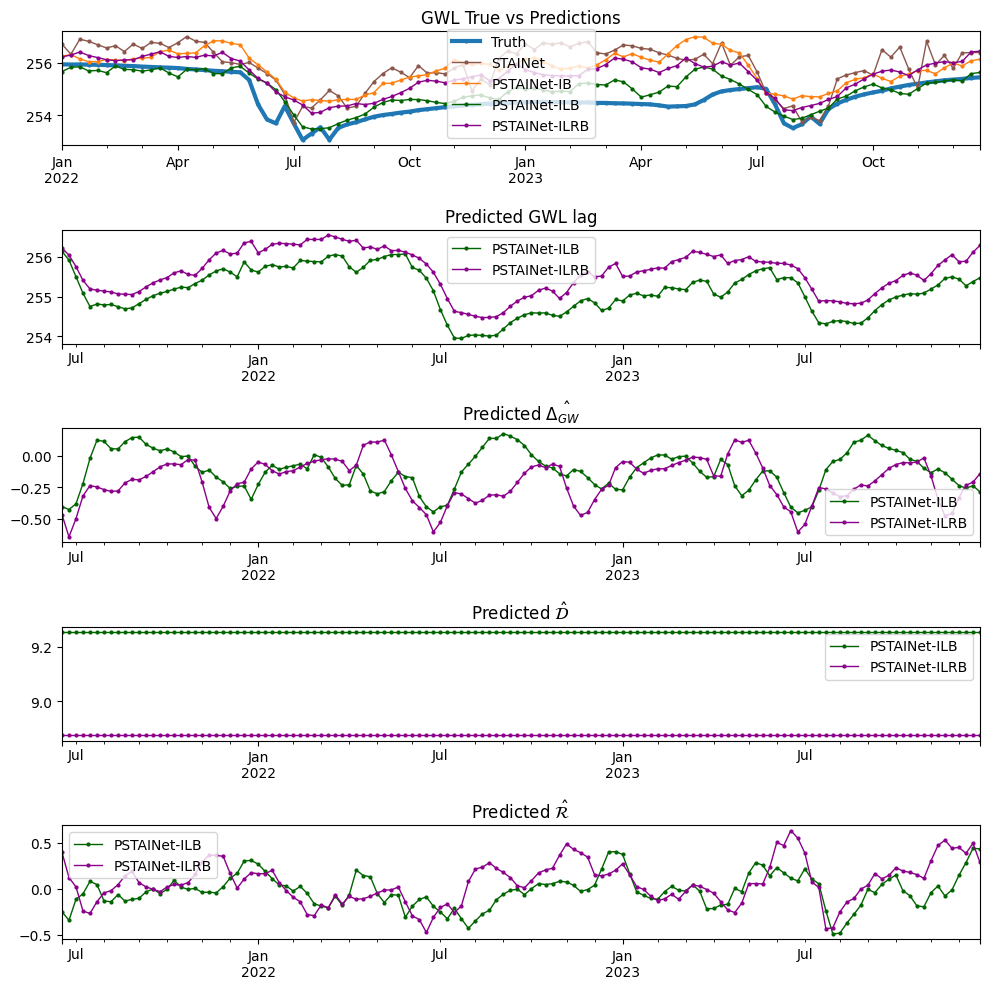

In [36]:
ts_plot_components("00126010001",
                       ds_truth,
                       dict_pred_gwl,
                       dict_pred_d,
                       dict_pred_deltagw,
                       dict_pred_laggwl,
                       dict_pred_r,
                       color_dict,
                       physics_model_list = ["PSTAINet-ILB","PSTAINet-ILRB"])

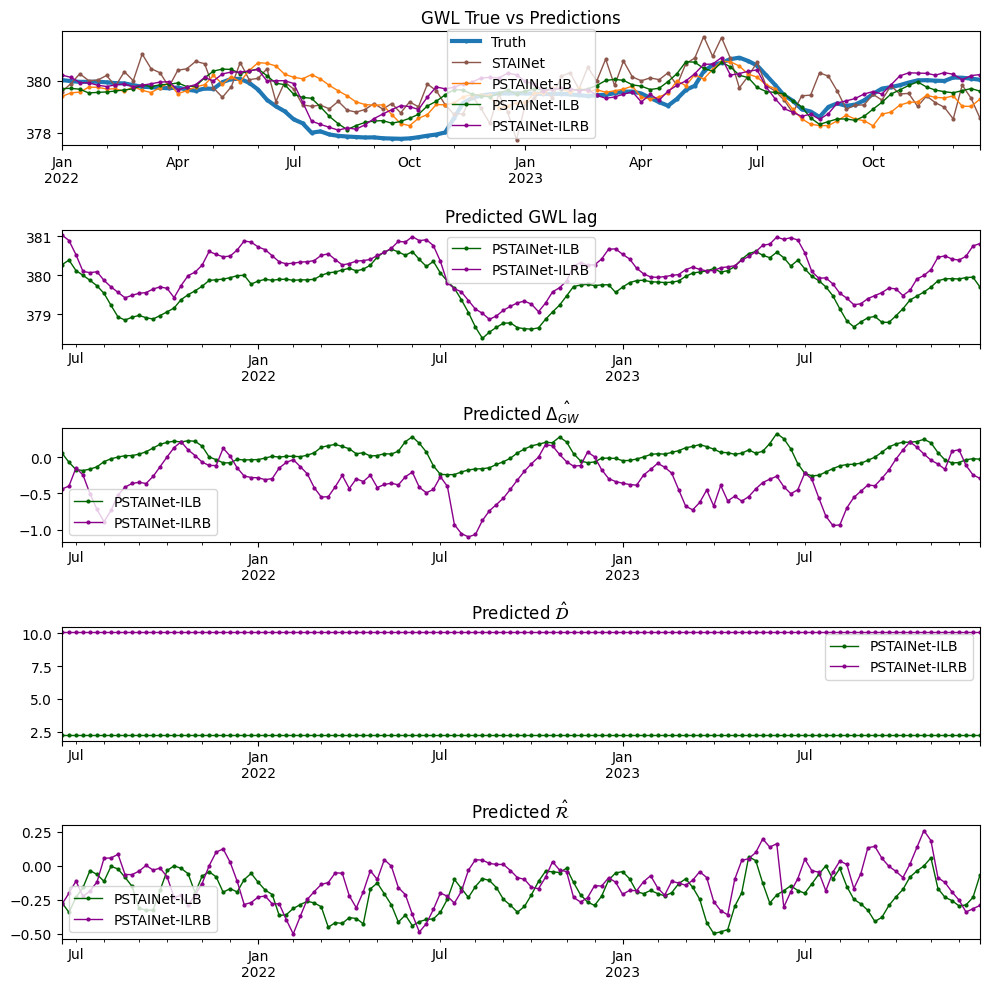

In [37]:
ts_plot_components("00425010001",
                       ds_truth,
                       dict_pred_gwl,
                       dict_pred_d,
                       dict_pred_deltagw,
                       dict_pred_laggwl,
                       dict_pred_r,
                       color_dict,
                       physics_model_list = ["PSTAINet-ILB","PSTAINet-ILRB"])

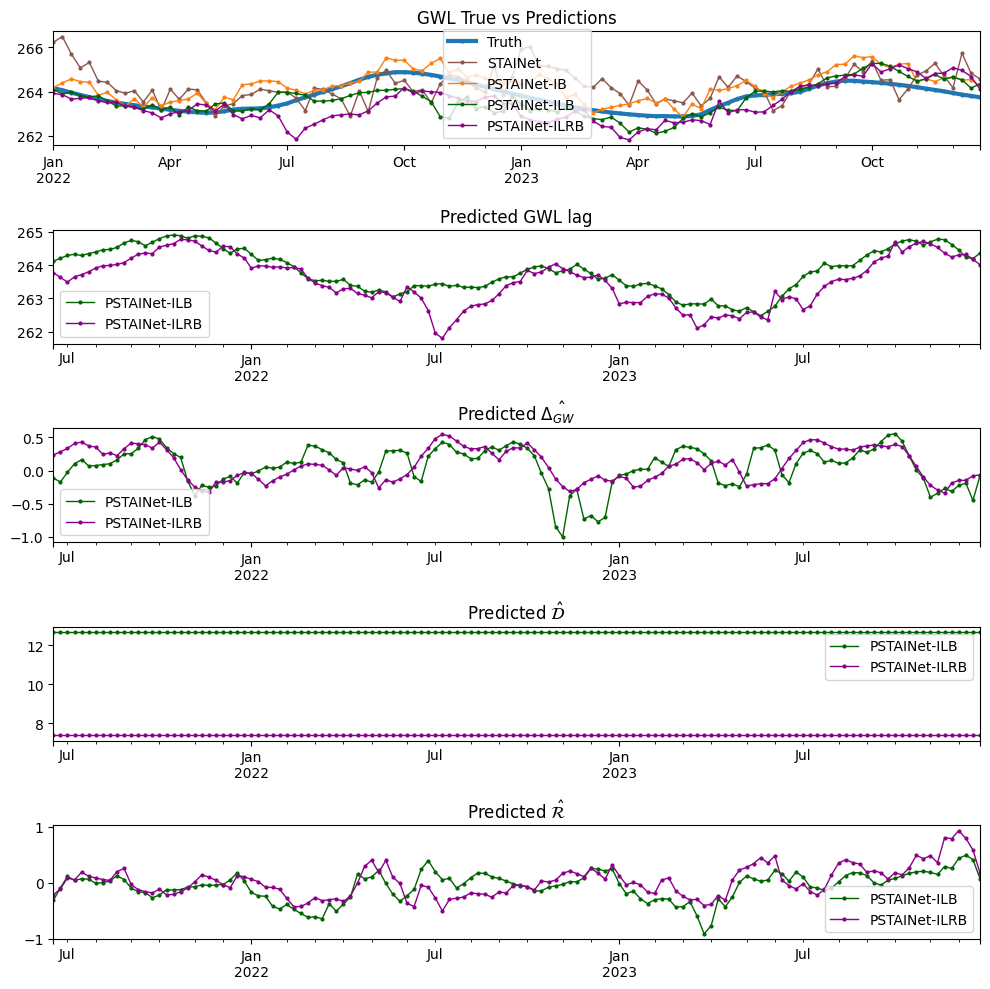

In [38]:
ts_plot_components("00109010001",
                       ds_truth,
                       dict_pred_gwl,
                       dict_pred_d,
                       dict_pred_deltagw,
                       dict_pred_laggwl,
                       dict_pred_r,
                       color_dict,
                       physics_model_list = ["PSTAINet-ILB","PSTAINet-ILRB"])

# Metrics

In [39]:
from utils.metrics import *

In [40]:
# import pred e iter pred


model_list = ["PSTAINet-IB","PSTAINet-ILB","PSTAINet-ILRB"]

In [46]:
# compute origianl metrics (check)
def compute_rmse(truth, predictions):
    
    for model in model_list:
        metric = compute_test_rmse_per_sensor(truth, predictions[model])
        median = metric.median()
        iqr = metric.quantile(0.75) - metric.quantile(0.25)
        print(f"Median and IQR RMSE for {model}: {median} +/- {iqr}")

In [ ]:
# ORIGINAL
compute_rmse(truth = ds_truth,
             predictions = dict_pred_gwl)

Median and IQR RMSE for PSTAINet-IB: 0.6295952200889587 +/- 0.8175062537193298
Median and IQR RMSE for PSTAINet-ILB: 0.5058221220970154 +/- 0.30309799313545227
Median and IQR RMSE for PSTAINet-ILRB: 0.652063250541687 +/- 0.5346876978874207


In [48]:
# TRUE VS LAG
compute_rmse(truth = ds_truth,
             predictions = dict_pred_laggwl)

Median and IQR RMSE for PSTAINet-IB: 46.77754592895508 +/- 39.74143981933594
Median and IQR RMSE for PSTAINet-ILB: 0.5658658146858215 +/- 0.42064693570137024
Median and IQR RMSE for PSTAINet-ILRB: 0.7988608479499817 +/- 0.5615969896316528


In [50]:
# TRUE VS LAG+R
dict_pred_laggwl_r = {model: dict_pred_laggwl[model] + dict_pred_r[model] for model in model_list}

compute_rmse(truth = ds_truth,
             predictions = dict_pred_laggwl_r)

Median and IQR RMSE for PSTAINet-IB: 31.75050163269043 +/- 24.653705596923828
Median and IQR RMSE for PSTAINet-ILB: 0.5627034306526184 +/- 0.36525824666023254
Median and IQR RMSE for PSTAINet-ILRB: 0.7572485208511353 +/- 0.542029619216919


## Component stats

In [38]:
dict_pred_deltagw["PSTAINet-IB"].mean()

00103510001    39.007015
00104110001   -17.085098
00105110001   -39.591908
00105910001   -43.333458
00105910002   -49.952263
00107010001   -25.478941
00109010001    -4.327207
00112710001   -48.187191
00117110001   -19.062086
00119710001   -28.587597
00126010001   -27.798828
00127210001   -36.321693
00127210003   -47.948723
00131010001   -39.816452
00401210001     2.372407
00402910001   -14.359262
00403410001    42.004528
00404110001   -31.036480
00405910001   -21.339371
00407810001    51.826874
00408910001     6.439580
00408910002    19.012737
00414310002   -42.879330
00417910001   -33.364086
00421510001    -9.146908
00421710001   -29.741396
00422510001    44.639828
00425010001    24.144724
dtype: float32

In [42]:
dict_pred_deltagw["PSTAINet-ILB"].mean().mean()

np.float32(-0.070339866)

In [41]:
dict_pred_deltagw["PSTAINet-ILRB"].mean().mean()

np.float32(-0.2079587)

In [48]:
dict_pred_r["PSTAINet-ILB"].mean().median()

np.float32(-0.13477002)

In [46]:
dict_pred_r["PSTAINet-ILRB"].mean().median()

np.float32(-0.07430637)